# More Data Mining and Machine Learning Techniques

Falando sobre outras técnicas de mineração de dados e aprendizado de máquina.  

<small>**OBS.:** Muitos termos eu posso acabar alterando o padrão de escrita, quero dizer, para quem trabalha na área e é familiarizado com os termos em inglês, o que não é o meu caso neste momento, pode se deparar com o termo escrito em português, eu percebi só agora, futuramente planejo me adaptar e seguir um padrão de escrita para continuar. Eu escrevo esses documentos para auxiliar na minha própria aprendizagem, como um caderno de anotações, por isso não existe um certo padrão de escrita, pois estou começando me familiarizar agora. Também, muita coisas aqui e em outros documentos são pegas da aula e são traduzidas, embora meu inglês não esteja tão bom assim, pode ser que em algum momento eu vá perceber que o termo fique melhor em inglês e vice-versa, podendo então no meio do documento simplesmente mudar apenas a palavra, mas o significado permanece o mesmo.</small>

## K-Nearest-Neighbors (k-NN)

Uma bem simples para começar, se chama de k-vizinhos mais próximos (k-NN), ela é uma técnica de aprendizado de máquina supervisionado simples, usada para classificação e regressão.  
Basicamente, a ideia de k-vizinhos mais próximos é a seguinte: digamos que eu tenha um conjunto de dados, que já foram classificados, que podem ser usados para treinar o sistema. Se eu tiver um novo ponto de dados, tudo o que faço pe analisar os k-vizinhos mais próximos com base nessa métrica de distância, deixando que todos votem na classificação desse novo ponto.  
Por mais que seja uma técnica simples, o que estou fazendo é apenas pegar os vizinhos mais próximos em um gráfico e dispersão e depois deixando que eles votem em uma classsifição.  

Agora vamos para prática, vamos aplicá-la a um problema mais complexo: prever a classificação de um filme com base em seu gênero e informações de classficação.

### K-Vizinhos Mais Próximos na Prática

Como exemplo, irei realizar um análise do dados do MovieLens. Vou tentar adivinhar a classificação de uma filme observando os 10 filmes mais semelhantes a ele em termos de gênero e popularidade.  

<small>**OBS:** O MovieLens é um sistema de recomendação de filmes baseado na web, não comercial e gratuito, criado em 1997 e mantido pelo GroupLens Research, um laboratório de pesquisa do Departamento de Ciência da Computação e Engenharia da Universidade de Minnesota. Fonte: Google</small>

In [31]:
# Para iniciar, tem que carregar todas as classificações do dataset em um DataFrame do Pandas

import pandas as pd

# O DataSet  está em um diretório do curso, eu copiei ele e alterei o nome do diretório para cumprir
# com as exigências do BootCamp (<nome>_aula.<tipo>), mas são muitos arquivos dentro do diretório, então alterei apenas o nome do diretório
r_cols = ['user_id', 'movie_id', 'rating']
# Aqui estou importando os arquivo de dados de classificações, o u.data e estou importanto as primeiras três colunas
# Elas representam respectivamente o ID do usuário, ID do filme e a classificação do filme da r_c
ratings = pd.read_csv('ml-100k_aula/u.data', sep='\t', names=r_cols, usecols=range(3))
ratings.head()

,user_id,movie_id,rating
0,0,50,5
1,0,172,5
2,0,133,1
3,196,242,3
4,186,302,3


Agora, irei agrupar tudo por ID do filme e calcular o número total de avaliações e a avaliação média de cada filme.

In [32]:
# Para isso irei usar o NumPy
import numpy as np

# O GroupBy do Pandas para agrupar pelo ID do filme e vai exibir o número de avaliações e a média para cada filme
# OBS.: Em uma versão futura do pandas, a função fornecida será usada diretamente. 
# Para manter o comportamento atual, passei a string "mean" em vez de np.mean.
# Antes: movieProperties = ratings.groupby('movie_id').agg({'rating': [np.size, np.mean]})
# Isso é só para tirar o FutureWarning
movieProperties = ratings.groupby('movie_id').agg({'rating': [np.size, "mean"]})
movieProperties.head()

rating          
           size      mean
movie_id                 
1           452  3.878319
2           131  3.206107
3            90  3.033333
4           209  3.550239
5            86  3.302326

O número bruto de avaliações não é muito útil para calcular a distância entre filmes, então criei um novo DataFrame que tem o número normalizado de avaliações. Desta forma, um valor de 0 significa que ninguém avaliou o filme, e um valor de 1 significa que é um filme mais popular.

In [33]:
movieNumRatings = pd.DataFrame(movieProperties['rating']['size'])
# Usa uma função lambda onde o pega o número máximo e mínimo de avaliações para cada filme
# Aplicamos para o DataFrame inteiro e então utilizamos o max e min do NumPy para normalizar tudo entre o intervalo
# do filme mais popular e menos popular, assim terei a popularidade de acada filme em uma escala de 0 a 1
# Onde 0 = ninguém assitiu ao filme e 1 = muitos assitiram ao filme
movieNormalizedNumRatings = movieNumRatings.apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)))
movieNormalizedNumRatings.head()

,size
movie_id,
1,0.773585
2,0.222985
3,0.152659
4,0.356775
5,0.145798


Agora para conseguir as informações de gênero do aquite u.item. Basicamente funciona da seguinte maneira: exixtem 19 campos, cada um correspondendo a um gênero específico, o valor `0` significa que o filme não pertence àquele gênero e `1` significa que pertence. Um filme também pode ter mais de um gênero associado a ele.  
Vou juntar tudo em um Dictionary Pytho chamado `movieDict` Cada entrada terá o nome do filme, a lista de valores de gênero, a pontuação de populariade normalizada e a classificação média de cada filme.

In [34]:
movieDict = {}
# Abre o arquivo, importante mudar o caminho para onde foi instalado
with open(r'ml-100k_aula/u.item', encoding="ISO-8859-1") as f:
    temp = ''
    # Para cada linha
    for line in f:
        #line.decode("ISO-8859-1")
        # Remove a quebra de linha e irei dividir o arquivo com base nos delimitadores de barra vertical
        fields = line.rstrip('\n').split('|')
        # Extrai o ID do filme
        movieID = int(fields[0])
        # Extrai o nome do filme
        name = fields[1]
        # Todos os campos de gêneros individuais
        genres = fields[5:25]
        genres = map(int, genres)
        # Constrói um dictionary que mapeia os IDs dos filmes para seus nomes e gêneros, também incluindo a classificação média e a popularidade de 0 a 1
        movieDict[movieID] = (name, np.array(list(genres)), movieNormalizedNumRatings.loc[movieID].get('size'), movieProperties.loc[movieID].rating.get('mean'))


Por exemplo, aqui está o filme de ID 1:

In [35]:
movieDict[1]

('Toy Story (1995)',
 array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 0.7735849056603774,
 3.8783185840707963)

Agora, vou definir uma função que calcula a "distância" entre dois filmes com base na similaridades de seus gêneros e em sua popularidade. Para garantir o funcionamento, irei calcular a distância entre os filmes de ID 2 e 4.

In [36]:
from scipy import spatial

# Função para calcular a distância entre dois filmes com base na similaridade
def ComputeDistance(a, b):
    # Pega os gêneros do filme a e b
    genresA = a[1]
    genresB = b[1]
    # Calcula baseado na similaridade de cosseno entre os dois vetores de gênero
    genreDistance = spatial.distance.cosine(genresA, genresB)
    # Pega a pontuação de popularidade dos filmes a e b
    popularityA = a[2]
    popularityB = b[2]
    # A distância da popularidade é o valor absoluto da diferença entre as duas pontuações
    popularityDistance = abs(popularityA - popularityB)
    return genreDistance + popularityDistance
    
ComputeDistance(movieDict[2], movieDict[4])

0.8004574042309892

Lembrando de que quanto maior a distância, menos semelhantes os filmes são. Como exemplo, vou verificar quais são os filmes 2 e 4 e confirmar se eles não são tão parecidos.

In [37]:
# Usando o print, ele imprime toda a informação em uma linha só, então vou apenas colocar sem ele
movieDict[2]

('GoldenEye (1995)',
 array([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]),
 0.22298456260720412,
 3.2061068702290076)

In [38]:
movieDict[4]

('Get Shorty (1995)',
 array([0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 0.3567753001715266,
 3.550239234449761)

Antes, vou precisar de um pequeno código para calcular a distância entre um determinado filme de teste (<i>Toy Story</i>, neste exemplo) e todos os filmes neste <i>dataset</i>. Em seguida, ordenar os filmes por distância e imprimir os K-Vizinhos mais próximos.

In [39]:
import operator

# Vai pegar o ID do filme e calcular a distância entre todos os outros filmes
# e classificar os resultados com base na pontuação de distância.
# movieID é o filme de interesse
# K são os vizinhos que quero encontrar
def getNeighbors(movieID, K):
    distances = []
    # Para todos os filmes do dicionário
    for movie in movieDict:
        # Se o filme for diferente do que estou analisando
        if (movie != movieID):
            # Ele calcula a pontuação de distância anterior
            dist = ComputeDistance(movieDict[movieID], movieDict[movie])
            # Adiciona na lista de resultados
            distances.append((movie, dist))
    # Ordenará os resultados
    distances.sort(key=operator.itemgetter(1))
    neighbors = []
    # Aqui ele vai selecionar os k melhores resultados
    for x in range(K):
        neighbors.append(distances[x][0])
    # Retorna esses resultados
    return neighbors

# Por exemplo, vou definir K = 10, para encontrar os 10 vizinhos mais próximos
K = 10
avgRating = 0
# Pega os 10 vizinhos mais próximos
neighbors = getNeighbors(1, K)
# Calcula a classificação média de cada um, essa classificação informará a previsão 
# de classificação para o filme em questão, também obterei os 10 vizinhos
# mais próximos com base na função de distância, podesse chamar de filmes semelhantes
for neighbor in neighbors:
    avgRating += movieDict[neighbor][3]
    print (movieDict[neighbor][0] + " " + str(movieDict[neighbor][3]))
    
avgRating /= K

Liar Liar (1997) 3.156701030927835
Aladdin (1992) 3.8127853881278537
Willy Wonka and the Chocolate Factory (1971) 3.6319018404907975
Monty Python and the Holy Grail (1974) 4.0664556962025316
Full Monty, The (1997) 3.926984126984127
George of the Jungle (1997) 2.685185185185185
Beavis and Butt-head Do America (1996) 2.7884615384615383
Birdcage, The (1996) 3.4436860068259385
Home Alone (1990) 3.0875912408759123
Aladdin and the King of Thieves (1996) 2.8461538461538463


Aproveitando que estou nisso, a classificação média dos 10 filmes mais próximos de Toy Story é:

In [40]:
avgRating

3.3445905900235564

## The Curse of Dimensionality

Refere-se a uma técnica chamada análise de componentes principais e a um técnica específica chamada decomposição em valores singulares (ou SVD).  
Muitos problemas podem ser considerados como tendo muitas diferentes dimensões, por exemplo, qunado estava fazendo recomendações de filmes, tinha atributos de vários filmes e cada filme individual podia ser considerados como sua própria dimensão nesse espaço de dados.  
Portanto, existem técnicas de redução de dimensionalidade para encontrar uma maneira de reduzir informações de alta dimensionalidade em informações de baixa dimensionalidade. O que não só facilita a visualização e a classificação, como pode ser útil para coisas como compressão de dados.  
Ao preservar a maior quantidade possível de variância enquanto reduzimos o número de dimensões, representamos um <i>dataset</i> de forma mais compacta, ao mesmo tempo que tentamos preservar a variância nesse <i>dataset</i>.  
Assim, uma aplicação comum da redução de dimensionalidade não se limita à visualização, mas também a compressão e à extração de características.  
Um exemplo muito simples de redução de dimensionalidade pode ser um agrupamento <i>k-means</i>. Por exemplo, podemos começar com muitos pontos que representam muitas dimensões diferentes em um <i>dataset</i> , mas, em última análise, podemos reduzir isso a k centroides diferentes e à distância até esses centroides.  
Essa é uma maneira de reduzir os dados a uma representação de menor dimensionalidade, mas geralmente, quando as pessoas falam sobre, elas estão falando sobre redução de dimesionalidade, uma técnica chamada análise de componentes principais.  
Essa é uma técnica bem mais sofisticada, que envolve matemática complexa , mas, em linhas gerais, tudo o que é preciso saber é que ela pega um espaço de dados de alta dimensionalidade e encontra planos dentro desse espaço de dados em dimesões superiores. Esses planos de alta dimensionalidade são chamados de hiperplanos e são definidos por elementos chamados autovetores. Você pega quantos planos quiser, com quantas dimensões desejar, e projeta os dados nesse hiperplanos, que se tornam os novos eixos no meu espaço de dados de baixa dimensionalidade. Em outras palavras, para quem já estudou álgebra linear, o que você faz é uma tranformação linear de um espaço de alta dimensionalidade para um espaço de baixa dimensionalidade.  

Agora que foi explicado os conceitos, basicamente a parte teórica de forma resumida, vamos para uma aplicação prática.

### Análise de Componentes Principais (PCA) na prática

O exemplo que estarei fazendo aqui é bem simples: o <i>dataset</i> Iris que vem com o <i>scikit-learn</i>. è apenas uma coleção de dados com quatro dimensões para três tipos diferentes de flores íris: o comprimento e a largura das pétalas e sépalas de muitas flores individuais da cada espécie.

In [41]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import pylab as pl
from itertools import cycle

# Carrega o dataset  
iris = load_iris()

# Extrai o o formato, que seria a quantidade de pontos de dados e as suas dimensões
numSamples, numFeatures = iris.data.shape
print(numSamples) # Quantidade de espécies
print(numFeatures) # Quantidade de dimensões (coomprimento e a largura da sépale e o comprimento e largura da pétala
print(list(iris.target_names)) # Classificações, são 3 espécies diferentes

150
4
['setosa', 'versicolor', 'virginica']


Mesmo que seja possível visualizar dados em 2 ou até 3 dimensões bem fácil, visualizar dados em 4D não é algo que nosso cérebro consiga fazer. Então, vou reduzir isso para 2 dimensões e ver como funciona.

In [42]:
# Atribui todo o conjunto de dados para X
X = iris.data
# Cria um modelo PCA onde é definido n componentes = 2, ele equivale a 2 dimensões
# o whiten definido como True signinfica que vou normalizar todos os dados, assim garantindo que tudo seja comparável
# e depois ajusta o modelo PCA ao dataset 
pca = PCA(n_components=2, whiten=True).fit(X)
# Agora transforma o dataset em duas dimensões
X_pca = pca.transform(X)

Basicamente o que fei feito foi destilar o dataset de 4D para 2D, projetando-o em dois vetores 4D ortogonais que formam a base para uma nova projeção 2D. Podesse ver quias são esses vetores 4D, mas não seria algo que desse pra entender completamente.  
O que aconteceu: criei um modelo PCA para reduzir quatro dimensões em duas dimensões, escolhendo dois vetores quadridimensionais para criar hiperplanos e projetar os dados quadridimensionais em duas dimensões.

In [43]:
# Os vetores quadridimensionais
print(pca.components_)

[[ 0.36138659 -0.08452251  0.85667061  0.3582892 ]
 [ 0.65658877  0.73016143 -0.17337266 -0.07548102]]


Agora observe quanta informação foi possível preservar:

In [44]:
# Esse primeiro seria a quantidade de variância que foi possível preservar
# Ele retorna um vetor, onde a primeira dimensão é a quantidade que foi possível preservar
# e a segunda dimensão é a qunatidade de adicional de variância
print(pca.explained_variance_ratio_)
# A soma das duas mostra a quantidade qua foi preservada dos dados originais
print(sum(pca.explained_variance_ratio_))

[0.92461872 0.05306648]
0.9776852063187963


Agora uma representação gráfica 2D desses dados:

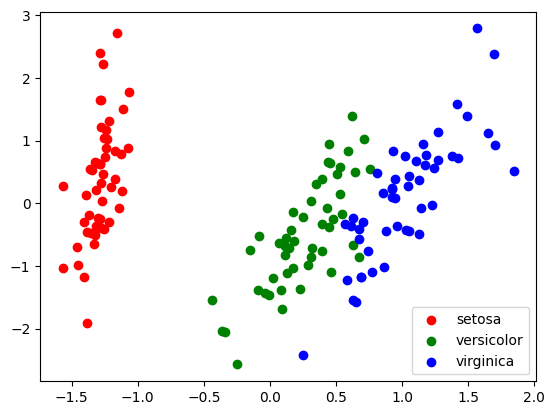

In [45]:
%matplotlib inline
from pylab import *

# Cria uma lista de cores (rgb)
colors = cycle('rgb')
# cria uma lista de IDs de alvos, para mapear as diferentes espécies de íris
target_ids = range(len(iris.target_names))
pl.figure()
# Itera pelas três espécies, terei o índice para cada espécie, uma cor associada e o nome do rótulo
for i, c, label in zip(target_ids, colors, iris.target_names):
    # Pegando uma espécie por vez, plota no gráfico de dispersão
    pl.scatter(X_pca[iris.target == i, 0], X_pca[iris.target == i, 1],
        c=c, label=label)
# Adiciona a legenda
pl.legend()
pl.show()

Veja que é possível observar que os três diferentes tipos de íris ainda estão bem agrupados. Isso provavelmente funciona bem porque o tamanho geral de uma flor individual provavelmente fas com que os tamanhos das pétalas e das sépalas aumentem em proporções semelhantes.  
Embora os números deste gráfico não tenham um significado intuitivo, o que provavelmente está sendo observado é uma medida das proporções entre a largura e a altura das pétalas e das sépalas.

## Data Warehousing Overview with ETL and ELT

<i>Data Warehousing</i> é basicamente um banco de dados gigante que contém informações de diversas fontes e as integra.  
Um <i>Data Warehousing</i> tem o desafio de coletar dados de várias fontes, transformando-os em um esquema que permite consultar essas diferentes fontes de dados de forma simultânea e conseguir <i>insights</i> por meio da análise de dados, utilizando essas fontes distintas.  
Grandes corporações e organizações costumam ter esse tipo de estrutura. 

### ETL: Extract, Transform, Load

É a maneira convencional de fazer <i>data warehousing</i>.  
Basicamente primeiro é realizado a extração de dados brutos que deseja dos sistemas operacionais.  
Depois transformar todas essas informações em uma tabela de banco de dados estruturada que seja possível importar para o meu <i>data warehouse</i>.  
Finalmente, os dados são carregados na <i>data warehousing</i>. É possível organizar em uma estrutura tabular que posso então carregar no <i>data warehousing</i>. O próprio <i>data warehousing</i> é uma tabela real em um banco de dados, então, à medida que os dados crescem, essa etapa de transformação pode se tornar um problema, pense, por exemplo, na quantidade de processamento que seria necessário para analisar todos os <i>logs</i> da <i>web</i> em <i>sites</i> como Google, Amazon ou qualquer outro grande <i>website</i> e tranformá-los em algo que um banco de dados possa interagir, isso, por si só, acaba se tornando um desafio de escalabilidade e pode introduzir problemas de estabilidade em todo o <i>pipeline</i> do <i>data warehousing</i>.  
É aí que entra o conceit de ELT.

### ELT: Extract, Load, Transform

Esse conceito é o que revoluciona tudo. Ele, basicamente, propõe:  
Em vez de usar uma enorme intância, usar algumas dessas técnicas mais recentes que permite ter um banca de dados mais distribuído em um cluster Hadoop.  
Isso permite aproveitar o poder desses bancos de dados distribuídos, construídos sobre Hadoop, como Hive, Spark ou MapReduce, e usá-los para realizar a transformação após o carregamento dos dados.  
A ideia aqui é extrair as informações desejadas, como era feito antes, depois carregá-las diretamente em no repositório de dados. Para usar o poder do próprio repositório para realizar a transformação no local.  
Basicamente, a ideia é, em vez de realizar um processo <i>offline</i> para transformar os meus <i>logs</i> da <i>web</i>, por exemplo, em um formato estruturado, eu simplesmente os importo como arquivos de texto brutos e os analiso linha por linha, usando o poder de algo como o Hadoop para transformá-los em um formato mais estruturado que posso consultar em toda a minha solução de <i>data warehousing</i>.  
Ferramentas como o Hive permitem hospedar um banco de dados massivo em um <i>cluster Hadoop</i>, e existem ferramentas como o Spark SQL que permitem fazer consultas de maneira bem semelhante a SQL em um <i>data warehousing</i> distribuído em um <i>cluster Hadoop</i>. Há também bancos de dados NoSQL distribuídos que podem ser consultados usando Spark e MapReduce. 

## Reinforcement Learning

A ideia por trás do aprendizado por reforço é que você tem um agente que explora um espaço, vamos usar o exemplo do Pac-Man, onde o agente é o Pac-Man e o espaço é o labirinto em que o Pac-Man está. Conforme avança, ele aprende o valor de diferentes mudanças de estado em diferentes condições. Por exemplo, o estado do Pac-Man pode ser definido pelo fato de haver um fantasma ao sul, uma parede a oeste e espaços vazios ao norte a ao leste. Isso pode deifinir o estado atual do Pac-Man, e as mudanças de estado que ele pode sofrer seriam mover-se em uma determinada direção e o sistema pode então aprender o valor de ir em uma determinada direção.  
Isso é o aprendizado por reforço. Conforme explora todo esse espaço, ele refina esses valores de recompensa para um determinado estado e pode então usar esses valores de recompensa armazenados para escolher a melhor decisão a ser tomada, dads as condições atuais.  
O benefício dessa técnica é que, uma vez explorado todo o conjunto de estados possíveis em que seu agente pode estar, você pode obter rapidamente um desempenho muito bom ao executar diferentes iterações. Basicamente, você pode criar um Pac-Man inteligente executando aprendizado por reforço e permitindo que ele explore os valores de diferentes decisões, que pode se comportar em diferentes estados e armazenar essa informação para tomar rapidamente a decisão correta, dado um estado futuro que ele vê em um conjunto desconhecido de condições.  
Uma implementação muito específica de aprendizado por reforço é  chamada de <i>Q-Learning</i>.

### Q-Learning

Então, você começa com um conjunto de estados ambientais, que vou chamar de $S$, e os estados possíveis são as condições ao redor do agente, como: há um fantasma perto de mim? Há uma pílula de poder na minha frente? Coisas assim. E eu tenho um conjunto de ações possíveis que posso tomar nesses estados, que irei chamar de ações. No caso do Pac-Man, essas ações possíveis são mover para cima, para baixo, para a esquerda ou para a direita.  
Então, temos um valor para cada par estado-ação, que irei chamar de $Q$. É por por isso é chamado de <i>Q-Learning</i>. Assim, para cada estado, ou seja, um determinado conjunto de condições ao redor do Pac-Man, uma determinada ação terá um valor $Q$. Então, mover para cima pode ter um determinado valor $Q$, mover para baixo pode ter um valor $Q$ negativo se significar encontrar um fantasma, por exemplo.  
Começamos com uma valor $Q$ de zero para cada estado possível. O Pac-Man pode estar em um labirinto e, à medida que explora, coisas ruins acontecem com ele. Reduzimos o valor $Q$ do estado  e que ele se encontrava naquele momento.  
Por exemplo, se o Pac-Man for comido por um fantasma, penalizamos qualquer ação que ele tenha realizado naquele estado. Já quando coisas boas acontecem, como quando ele come uma pílula de poder ou um fantasma aumentamos o valor $Q$ daquela ação no estado em que ele estava.  
Podemos usar esses valores $Q$ para orientar as escolhas futuras do Pac-Man e construir um pequeno agente inteligente que possa ter um desempenho ótimo criando um Pac-Man perfeito.  
Dá para "prever" mais de um passo usando um fator de desconto ao calcular:  
$Q(s, a) += desconto * (recompensa(s, a) + max(Q(s')) - Q(s, a))$  
$s$ é o estado anterior e $s'$ é o estado atual.  

Um problema qe temos no aprendizado por reforço é o problema da exploração: como garantir que eu cubra eficientemente todos os diferentes estados e ações dentro desses estados durante a fase de exploração? Uma abordagem ingênua seria smepre escolhar a ação para um determinado estado com o maior valor $Q$ que calculei até o momento e, se houver um empate, escolher aleatoriamente.  
Inicialmente, todos os meus valores $Q$ podem ser zero e eu escolheria as ações aleatoriamente no começo. À medida que começo a obter informações sobre melhores valores $Q$ para determinadas ações em que determinados estados, começo a usá-los. Mas isso acaba sendo bastante ineficiente e posso perder muitos caminhos dessa forma se me prender a esse algoritmo rígido de sempre escolher o melhor valor $Q$ que calculei até o momento.  
Uma maneira melhor é introduzir um pouco de variação aleatória em minhas ações enquanto exploro, isso é chamado de termo epsilon. Temos um valor que eu rolo um dado, um número aleatório, e se ele for menor que esse valor epsilon, na verda, eu não consigo o valor $Q$ mais alto, eu não faço o que faz sentido, eu simplesmente escolho um caminho aleatório para testar e ver o que acontece. Isso e permite explorar uma gama muito maior de possibilidades e ações para uma gama maior de estados, de forma mais eficiente durante a fase de exploração. 

### Termos Matemáticos

O que acabou de ser feito pode ser descrito em termos matemáticos sofisticados.  
Conceitualmente, é bem simples: eu exploro um conjunto de ações que posso tomar para um determinado conjuntos de estados, uso isso para definir aas recompensas associadas a uma determinada ação para um determinado conjunto de estados e, após essa exploração, posso usar essas informações — esses valores $Q$ — para navegar de forma inteligente por um labirinto completamente novo, por exemplo.  
Mas isso também pode ser chamado de processo de decisão de Markov, é uma estrutura matemática para modelar a tomada de decisões: qual ação tomar, dado um conjunto de possibilidades para um determinado estado, em situações onde os resultados são parcialmente aleatórios, como na nossa exploração aleatória e parcialmente controlados.  
O controle de um tomador de decisões, sendo o tomador de decisões os nossos valores $Q$ que calculamos. Portanto, os Processos de Decisão de Markov (MDPS) são uma forma sofisticada de descrever o algoritmo de exploração que acabamos de descrever para aprendizado por reforço, e a notação é semelhante.  
Os estados ainda são descritos como $s$, e $s'$ é o próximo estado que encontramos.  
Temos funções de transição de estado definidas como $P_a(s, s')$ e nossos valores $Q$ são basicamente representados como uma função de recompensa, então $R_a(s, s')$ é um valor para um dado $s$ e $s'$.  
Assim, a transição de um estado para outro tem uma recompensa associada, e essa transição é definida por uma função de transição de estado. 

### Programação Dinâmica

Programação dinâmica também pode ser usada para descrever o que fizemos anteriormente.  
Basicamente, é um método para resolver um problema complexo, como criar um Pac-Man inteligente, que é um resultado final bem complicado, dividindo-o em uma coleção de subproblemas mais simples. Por exemplo, qual é a ação ideal a ser tomada em um determinado estado em que o Pac-Man pode estar? Existem muitos estados diferentes em que o Pac-Man pode se encontrar, mas cada um desses estados representa um subproblema mais simples, onde há um conjunto limitado de escolhas que posso fazer e uma única resposta correta para a melhor jogada.  
E armazenando suas souções, essas soluções sendo os valores $Q$ que associei a cada ação possível em cada estado, inicialmente usando uma estrutura de dados baseada em memória. Bem, é claro que preciso armazenar esses valores $Q$ e associá-los aos estados de alguma forma. Na próxima vez que o mesmo subproblema ocorrer, na próxima vez que o Pac-Man estiver em um determinado estado para o qual eu tenha um conjunto de valores $Q$, em vez de recalcular a solução, basta consultar a solução calculada anteriormente, o valor $Q$ já tenho da fase de exploração. Dessa forma, economizando tempo de computação à custa de um espaço de armazenamento adicional modesto. É exetamente isso que fizemos com o aprendizado por reforço: temos um fase de exploração complexa que encontra as recompensas ideais associadas a cada ação para um determinado estado. Uma vez que temos essa tabela com as ações corretas para um determinado estado. podemos usá-la rapidamente para fazer nosso Pac-Man se mover de maneira otimizada em um labirinto totalmente novo que ele nunca viu antes.  
Portanto, o apredizado por reforço também é uma forma de programação dinâmica.

### Aprendizado por Reforço e Q-Learning com Gym na Prática

Basicamente, vou descrever o "problema do táxi". Quero construir um táxi autônome que possa pegar passageiros em um de um conjunto de locais fixos, deixá-los em outro lugar e chagar lá no menor tempo possível, evitando obstáculos.

In [46]:
import gym
import random

# Dá uma semente aleatória para obter os mesmos resultados sempre
random.seed(1234)

# Cria um ambiente chamado Taxi-v3, o modelo resultante se chamará de streets
streets = gym.make("Taxi-v2").env
streets.reset()
# Agora renderiza ele para que seja possível visualizar como esse ambiente se parece
streets.render()

+---------+
|R: | : :G|
| : : : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



R, G, B e Y são os locais de embarque e desembarque.  
A letra azul indica de onde precisa buscar o passageiro e a letra magenta indica para onde o passageiro deseja ir, as linhas contínuas representam paredes que o táxi não pode atravessar e o retângulo preenchido representa o própriao táxi, ele fica amarelo quando está vazio e verde quando está com um passageiro.  
Este pequeno mundo aqui, que é chamado de "ruas", é uma grade 5x5. O estado desse mundo a qualquer momento pode ser definido por:  
- Onde o táxi está (uma das 25 localizações).
- Qual é o destino atual (4 possibilidades).
- Onde o passageiro está (5 possibilidade: em um dos destinos ou dentro do táxi).
  
Sendo assim, existem um total de 25 x 4 x 5 = 500 estados possíveis que descrevem este mundo.  
Para cada estado, existem seis sç~es possíveis:
- Mover-se para o Sul,, Leste, Norte ou Oeste.
- Pegar um passageiro.
- Deixar um passageiro.
  
O aprendizado por reforço (<i>Q-Learning</i>) ocorrerá usando as seguintes recompensas e penalidades em cada estado:
- Um embraque bem-sucedido concede +20 pontos.
- Cada passo dado enquanto transporta um passageiro resulta em uma penalidade de -1 ponto.
- Pegar ou deixar um passgeiro em um local proibido resulta em uma penalidade de -10 pontos.
- Mover-se através de uma parede é totalmente proibido.
  
Vou definir um estado inicial, com o táxi na localização (2, 3), o passageiro no ponto de embarque 2 e destino na localização 0:

In [47]:
# Define o estado inicial
initial_state = streets.encode(2, 3, 2, 0)
# Atribui esse estado inicial para rua
streets.s = initial_state
# Renderiza para a visualizaçção
streets.render()

+---------+
|R: | : :G|
| : : : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



Agora para dar uma olhada na tabela de recompensas iniciais.

In [48]:
streets.P[initial_state]

{0: [(1.0, 368, -1, False)],
 1: [(1.0, 168, -1, False)],
 2: [(1.0, 288, -1, False)],
 3: [(1.0, 248, -1, False)],
 4: [(1.0, 268, -10, False)],
 5: [(1.0, 268, -10, False)]}

Cada linha corresponde a uma ação potencial neste estado:  
- Mover-se para o Sul, Norte, Leste ou Oeste.
- Pegar um passageiro.
- Deixá-lo em outro lugar.

Os quatro valores representam a probabilidade atribuída a essa ação, o próximo estado resultante dessa ação, a recompensa por essa ação e se essa ação indica que a entrega foi bem-sucedida.  
Por exemplo, mover-se para o Norte a partir deste estado me levaria ao estado número 368, incorreria em uma penalidade de -1 por consumir tempo e não resultaria em uma entrega bem-sucedida.  
Agora, irei usar o aprendizado por reforço. Primeiro, precisa treinar o modelo. Em linhas gerais, treinarei mais de 10.000 corridas de táxi simuladas. Para cada corrida, avançarei no tempo, com 10% de chance a cada passo de realizar uma ação exploratória aleatória em vez de usar os valores Q aprendidos para seguir essas ações.

In [49]:
import numpy as np

# Define uma tabela de dicas, ela é um array NumPy que tem uma matriz 2D
q_table = np.zeros([streets.observation_space.n, streets.action_space.n])

# Taxa de aprendizado, basicametne define a velocidade de aprendizagem
learning_rate = 0.1
# Fator de desconto
discount_factor = 0.6
# Taxa de exploração, como dito anteriormente é de 10%
exploration = 0.1
# Número de epochs que serão usadas para o treinamento, também dito anteriormente que serão 10.000
epochs = 10000

# Percorre essas 10.000 epochs
for taxi_run in range(epochs):
    # Reinicia o campo de jogo
    state = streets.reset()
    done = False
    
    while not done:
        # Sorteia um número aleatório entre 0 e 1
        random_value = random.uniform(0, 1)
        # Se o número sorteado for menor que a taxa de exploração
        if (random_value < exploration):
            # Explora uma ação aleatória
            action = streets.action_space.sample() # Explore a random action
        # Senão
        else:
            # Usa o maior valor Q associado às ações disponíveis
            action = np.argmax(q_table[state]) # Use the action with the highest q-value

        # Chama o step para aplicar a ação
        next_state, reward, done, info = streets.step(action)
        # O step retorna o próximo estado resultante, a recompensa resultante, se treminou ou não, se deixou o passageiro com sucesso e mais algumas informações
        prev_q = q_table[state, action]
        next_max_q = np.max(q_table[next_state])
        # Aplica a equação de Q-Learning, essa seria a versão em código
        new_q = (1 - learning_rate) * prev_q + learning_rate * (reward + discount_factor * next_max_q)
        # Atribui a tabela Q para aquele estado específico em ação ao valor Q recém-aprendido
        q_table[state, action] = new_q

        # Define o estado para o próximo estado e repete o processo até finalmente deixar o passageiro
        state = next_state

Agora que consegui a tabela de valores Q, pode ser usada para determinar o próximo passo ideal para qualquer estado dado.  
Agora vamos verificar a tabela para o estado inicial acima:

In [50]:
q_table[initial_state]

array([-2.39261984, -2.38756925, -2.39781614, -2.3639511 , -7.94953291,
       -7.19007158])

O menos valor de Q na tabela corresponde à ação "ir para o oeste", até que faz sentido, já que essa rota é a mais próxima para o destino a partir desse ponto.  
Agora vamos ver na prática.

In [51]:
from IPython.display import clear_output
from time import sleep

# Aqui vai simular 10 viagem diferentes
for tripnum in range(1, 11):
    state = streets.reset()
   
    done = False
    trip_length = 0
    
    while not done and trip_length < 25:
        action = np.argmax(q_table[state])
        next_state, reward, done, info = streets.step(action)
        clear_output(wait=True)
        print("Trip number " + str(tripnum) + " Step " + str(trip_length))
        # Removi o mode='ansi', o erro que deu era que não existia o arqumento mode
        print(streets.render(mode='ansi'))
        sleep(.5)
        state = next_state
        trip_length += 1
    sleep(1)

Trip number 10 Step 11
+---------+
|R: | : :G|
| : : : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)



## Matrizes de Confusão

Às vezes, a precisão não conta toda a história, um teste para uma doença rara pode ter 99,9% de precisão siplesmente chutando "não" o tempo todo, por exemplo. É preciso entender os verdadeiros positivos e os verdadeiros negativos, bem como os falsos positivos e os falsos negativos, para ser capaz de medir o quão bom seu modelo é em cada um desses casos, e uma matriz de confusão mostra isso.  
Uma matriz de confusão vai ser uma maneira ilustrar as nuances da acurácia do modelo.  
Uma matriz de confusão pode ter a seguinte aparência:  

##### Matriz de Confusão Binária
|  | Sim atual | Não atual |  
|---|---|---|
| **Sim previsto** | Positivo Verdadeiro | Positivo Falso |  
| **Não previsto** | Negativo Falso | Negativo Verdadeiro |  

<small><sup>**OBS.:** Foi uma confusão fazer essa tabela, realmente faz juz ao nome "matriz de confusão".</sup></small>

Bom... Acredito que seja bem óbvio essa tabela. Porém, em uma matriz de confusão real, essas células conteriam os números reais de quantas vezes o modelo fez isso no <i>dataset</i> de teste.  
Portanto, lembre-se de prestar ateção aos rótulos, não há uma convenção real para a ordem dos dados. Às vezes, será observado previsão e valores reais aqui. Não pode assumir que uma determinada matriz de confusão tem um formato específico, tem que prestar atenção em como ela está rotulada e se certificar de entender o que ela está indicando antes de tirar conclusões.  
Algo importante a observar é que geralmente, queremos que a maioria dos seus valores esteja aqui, então, a diagonal de matriz de confusão é onde a maioria dos resultados deve estar. Um modelo preciso teria números altos ao longo dessa diagonal.  
Inserindo alguns números reais para ver como isso ficaria: digamos que tenha um modelo de aprendizado de máquina que está tentando descobrir se uma imagem contém a foto de um gato ou não.  

##### A imagem tem um gato?
| | É gato real | Não é um gato real |
|---|---|---|
| Preveu um gato | 50 | 5 |
| Não preveu um gato | 10 | 100 |

Se eu previ que havia um gato e realmente havia um gato, isso aconteceu 50 vezes no meu conjunto de teste. Mas às vezes eu previ que era um gato, mas não era um cachorro, um peixe ou algo assim, isso aconteceu cinco vezes.  
Se eu previ que não era um gato, mas realmente era, isso aconteceu dez vezes neste exemplo. E se eu disse que não era um gato e... Na verdade, não se tratava de um gato que se repetiu 100 vezes neste caso, então é assim que interpreta uma matriz de confusão e falaremos em breve sobre como criar métricas mais úteis para análise a partir desses dados.  
Às vezes, será encontradas matrizes de confusão em um formato diferente, onde somando os valores em cada linha e coluna. Isso é algo que pode ser visto de vez em enquando. Basicamente, soma quantos nós reais temos, quantos "sim" reais temos, quantos nós previsto temos e "sim" previstos temos no total.  

##### Outro formato
| | Não previsto | Sim previsto | |
|---|---|---|---|
| Não atual | 50 | 5 | 55 |
| Sim atual | 10 | 100 | 110 |
| | 60 | 105 | |

A parte interna, no entanto, é a mesma matriz de confusão que vimos antes. E, novamente, lembre-se de que os valores previstos e os valores reais podem ser invertidos, então tem que certificar de prestar atenção aos rótulos.  
<small>**OBS.:** Matrizes de confusão podem ser... confusas, palavras do professor do curso.</small>  

Às vezes, poderá ter outro tipo de formata também. Digamos que temos um modelo de multiclassificação aqui também.

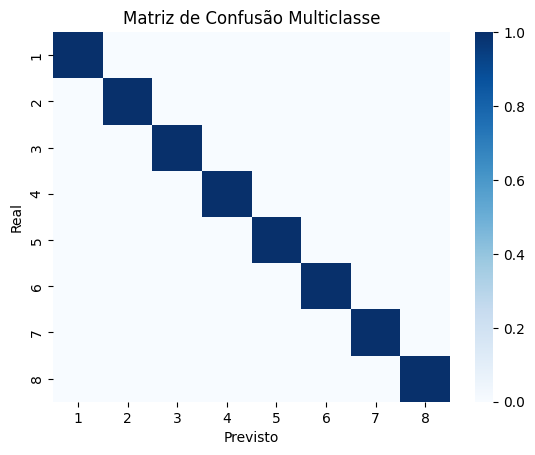

In [52]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pandas as pd

# Rótulos verdadeiros e as previsões do seu modelo
y_true = ["1", "2", "3", "4", "5", "6", "7", "8"]
y_pred = ["1", "2", "3", "4", "5", "6", "7", "8"]
labels = ["1", "2", "3", "4", "5", "6", "7", "8"]

# Calcula a Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)

# Converte para um DataFrame para facilitar a manipulação dos labels
df = pd.DataFrame(cm, index=labels, columns=labels)

# Cria o Mapa de Calor com Seaborn
plt.figure() # Define o tamanho da figura
sns.heatmap(df, 
            fmt='d', # Formato 'd' para inteiros
            cmap='Blues', # Mapa de cores
            cbar=True # Mostra a barra de cores
           )

plt.ylabel('Real')
plt.xlabel('Previsto')
plt.title('Matriz de Confusão Multiclasse')
plt.show()

<small>**OBS.:** Sim, eu tentei fazer uma parecida com a que eu vi na aula... Mas não saiu igual.</small>  

Imagine que temos um sistema de reconhecimento de escrita à mão que está tentando identificar alguém escrevendo o valor zero até nove, então uma matriz de confusão mais complexa poderia ser assim, onde em vez de apenas respostas sim ou não, temos múltiplas classificações, mas funciona da mesma maneira. Nesta matriz de confusão temos que rótulos previstos em um eixo e os rótulos verdadeiros neste eixo. Então, estamos dizendo que se eu previ que algo era um cinco e realmente era um, bem, nesse tom de azul corresponde a algum número (acredito que ele esteja falando do mapa de cores em relação as células, ele pode estar falando de algumas células que estão bem claras no exemplo dele, porém, como disse na observação, não consegui fazer a matriz igual ao exemplo, principalmente porque não fiz baseada em algum conjunto de dados). Duas coisas são diferentes neste exemplo:  
- Temos mais do que opções de sim ou não.
- Temos múltiplas classificações.  

Então minha matriz de confusão é maior.  
Também estopu usando o que é chamada de mapa de calor (é o mapa de cores na lateral). Em vez de apenas exibir números nas células individuais, estou mapeando esses números para colunas, onde a instensidade cor corresponde à magnitude do número. Assim como na matriz de confusão binária, o esperado é ver uma linha escura descendo na diagonal representando uma boa precisão em verdadeiros positivos e verdadeiros negativos. Idealmente, cores mais claras e esparsas fora da diagonal seriam ideiais, mas essa cor corresponderá a um valor real, o que facilita a visualização de como sua matriz de confusão está organizada.

## Métricas para Modelos

Agora falando sobre algumas métricas que posso derivar de uma matriz de confusão. Revendo a matriz de confusão binária, neste exeplo específico, temos os valores reais nas colunas e os valores previstos nas linhas. Lembre que isso pode variar, esse deve ser o terceiro aviso. Então, quando começar a analisar uma matriz de coonfusão preste atenção no <i>layout</i> dela.

##### Relembrando da nossa querida amiga: a Matriz de Confusão
| | Sim atual | Não atual |  
|-|-|-|
|<span style="background-color:gray;"> **Sim previsto** </span>| Verdadeiro positivo | Falso positivo |
| **Não previsto** | Falso negativo | Verdadeiro negativo |  

Começando com o Recall (revocação).  

### Recall
O <i>Recall</i> é calculado como a razão entre verdadeiros positivos e verdadeiros psoitivos + falsos negativos.  
$\frac{Verdadeiro Positivo}{Verdadeiro Positivo + Falso Negativo}$  
Isso é algo que deve memorizar e saber. Ela também é conhecida por outros nomes, normalmente devem fazer isso só para complicar um pouco as coisas: sensibilidade, taxa de verdadeiros positivos e completude.  
A completude, de certa forma, remete ao seu original no mundo da informação, então é uma boa escolha. Métrica quando se preocupa muito com falsos negativos, detecção de fraudes é um ótimo exemplo de um pode-se concentrar no <i>Recall</i>, porque um falso negativo no mundo da fraude significa que algo era fraude, mas o modelo não conseguiu identificá-lo como tal, você teve uma trasação fraudulenta que foi sinalizada como perfeitamente normal. Esse é o pior resultado possível em um sistema que que detecta fraudes.  
Nesse caso, eu quero para o lado dos falsos positivos e não dos falsos negativos. Então, <i>Recall</i> é uma boa escolha. Simétrica quando você se preocupa com falsos negativos, sendo a detecção de fraudes um exemplo disso, temos verdadeiros positivos sobre verdadeiros positivos mais falsos negativos.  

##### Exemplo de Recall
|| Fraude real | Fraude Falsa |
|-|-|-|
| **Fraude prevista** | 5 | 20 |
| **Fraude não prevista** | 10 | 100 |  

$Recall = \frac{VP}{VP + FN}$  
VP: Verdadeiro Positivo  
FN: Falso Negativo  

$Recall = \frac{5}{5+10} = \frac{5}{15} = \frac{1}{3} = 33\%$

Então, neste exemplo de uma matriz de confusão, nós simplesmente extraímos os valores desta matriz neste layout específico. Então, essa é a recuperação.  
A precisão é um fator crucial.

### Precisão

Ela é calculada como verdadeiros positivos divididos pela soma de verdadeiros positivos e falsos positivos:  
$\frac{Verdadeiros Positivos}{Verdadeiros Positivos + Falsos Positivos}$  
<small> Talvez você veja esta fórmula: $\frac{VP}{VP + FP} </small>  

Como o <i>Recall</i> ela pode ser conhecida por outros nomes, incluindo a taza de acerto ou a porcentagem de resultados relevantes.  
Portanto, essa é uma medida no mundo da recuperação de informações. Quando deve se preocupar com a precisão? Bem, é uma métrica importante quando se preocupa com falsos positivos.  
Alguns exemplos seriam exames médicos ou teste de drogas. Você não quer dizer que alguêm está usando cocaína ou algo do tipo quando não está, pois isso teria efeitos muito na sua vida e carreira. Então novamente, a  precisão é quando você se preocupa com falsos positivos do que com falsos negativos.  
Teste de drogas são um exemplo clássico disso. Agora um exemplo:  

##### Exemplo de Precisão
|| Fraude real | Fraude Falsa |
|-|-|-|
| **Fraude prevista** | 5 | 20 |
| **Fraude não prevista** | 10 | 100 |  

$Precisão = \frac{VP}{VP + FP}$  
$Precisão = \frac{5}{5 + 20} = \frac{5}{25} = \frac{1}{5} = 20\%$

### Outras Métricas

Existem outras métricas, por exemplo a especificidade que é a razão entre verdadeiros negativos e verdadeiros negativos mais falsos positivos.  
$Especificidade = \frac{Verdadeiros Negativos}{Verdadeiros Negativos + Falsos Positivos} = Taxa de Verdadeiros Negativos$  
<small> Ou: $Especificidade = \frac{VN}{VN + FP}$  

A F1 Score, é uma métrica muito comum. Ela pode ser calculada como:  
$\frac{2 * Verdadeiros Positivos}{2 * Verdadeiros Positivos + Falsos Positivos + Falsos Negativos}$  
<small> Ou: $\frac{2VP}{2VP + FP + FN}$</small>  
Ou como:  
$2 * \frac{Precisão * Recall}{Precisão + Recall}$  
Matematicamente as duas funcionam. E a pontuação F1 (F1 Score) é a média harmônica da precisão e da sensibilidade.  
Portanto, se você se importa com precisão e <i>recall</i> (tô quase mudando para <i>recall</i> para recuperação ou revocação), lembre-se de que <i>recall</i> e sensibilidade são a mesma coisa (e o cara só avisa depois que escrevi todo esse texto).  
A pontuação F1 (F1 Score) é uma métrica que equilibra as duas, Se você sabe que seu não se preocupa apenas com a acurácia e deseja capturar tanto a precisão quanto a revocação, a pontuação F1 pode ser uma maneira de fazer isso.

### RMSE (Raiz do Erro Quadrático Médio)

Ele também é frequentemente usado como métrica e é simplesmente uma medida direta de acurácia e é exatamente o que parece: a raiz do erro quadrático médio.  
Você apenas soma todos os erros quadráticos de cada previsão. É o valor real e a raiz quadrada dele, só isso.  
Ele só se importa com respostas certas e erradas, não entra nas nuances de precisão e <i>recall</i>. Então, se tudo o que quer é acurácia, o RMSE é uma métrica comum usada para isso.

### ROC Curve

Mais uma manneira de avaliar os modelos é a curva ROC (Receiver Operating Characteristic Curve).  
Ela plota a taxa de verdadeiros positivos ou <i>recall</i> versus a taxa de falsos positivos em várias configurações de limiar no seu modelo. Assim, conforme dá para escolher diferentes limiares entre verdadeiro e falso.  
Basicamente, a maneira de interpretar uma curva ROC é você quer que esteja acima da linha diagonal. O idela seria que a curva fosse um único ponto no canto superior esquerdo, com grande ângulo reto, onde tudo está no lado superior esquerdo do gráfico, à esquerda da linha diagonal.  
Quanto mais curvada a curva ROC estiver em direção ao canto superior esquerdo, melhor. É assim que se interpreta essas coisas.  
Infelizmente não vou conseguir fazer uma dessas usando o Matplotlib ou Seaborn, gostaria de fazer usando algum dado real, fica mais legal.

### AUC

Também dá para falar sobre a área sob a curva, que é exatamente o que parece. Podesse interpretar esse valor como... A probabilidade de um classificador a instância positiva escolhida aleatoriamente acima de uma instância negativa escolhida aleatoriamente é de 0,5. Portanto, um AUC de 0,5 seria o esperado se você estiver na linha diagonal. Se estivesse a área abaixo dessa linha diagonal onde não são melhores do que aleatórias, essa área seria de 0,5.  
Então se vir um AUC de 0,5 ou menos, é inútil ou pior do que inútil. O classificador perfeito teria uma área sobre a curva com um AUC de 1,0 (o gráfico que ele mostra é o mesmo que da curva ROC, ele vai de uma escala de 0 a 1 em ambos eixos). Esse seria o caso perfeito, onde a curva forma um ângulo reto com 1,01 no canto superior esquerdo, que incluiria a área do gráfico, resultando em um. Assim, o AUC pode ser uma métrica útil para comparar diferentes classificadores, onde quanto maior o valor, melhor.

# Dealing with Real-World Data

Começando uma nova seção, agora vai ser falado sobre os desafios de lidar com dados do mundo real e algumas peculiaridades que podem ser encontradas.  
Começando a falar sobre a relação entre viés e variância, que é uma maneira mais formal de abordar as diferentes formas de sobreajuste e subajuste dos dados e como tudo isso se inter-relaciona.

## O Equilíbrio entre Viés e Variância

Um dos principais desafios que enfretamos (no meu caso que estou no topo do iceberg, enfretarei) ao lidar com dados do mundo real é o sobreajuste versus o subajuste das regressões de dados, dos modelos ou das previsões. Quando fala de subajuste e sobreajuste, muitas vezes pode-se abordá-los no contexto de viés e variância e da relação entre viés e variância.  

### Viés e Variância

Conceitualmente, viés e variância são bem simples:  
- **Viés** é o quão distante você está dos valores corretos, ou seja, quão boas são suas previsões em geral para prever o valor correto? Se você calcular a média de todas as suas previsões, elas estão mais ou menos no ponto certo ou seus erros estão consistentemente enviesados em uma direção ou outra?
  Se sim, então suas previsões são enviesadas.
- A **Variância** em determinada direção é simplesmente uma medida de quão dispersas estão suas previsões. Se suas previsões estiverem espalhadas por toda parte, isso indica alta variância, mas se elas estiverem bem focadas nos valores corretos, ou mesmo em um valor incorreto (no caso de alto viés), então sua variância é pequena.  
Um exemplo, imagine que um alvo de dardos representa uma série de previsões, onde o valor real que estamos tentando prever está no centro do alvo.

Se nosso pontos estão todos espalhados ao redor do centro. No geral o erro médio fica bem próximo da realidade. Nosso viés é muito baixo, porque nossas previsões estão todas espalhadas em torno do mesmo ponto correto. No entanto, temos uma variância muito alta, por que esses pontos estão espalhados por toda parte. Este é um exemplo de baixo viés e alta variância.
Se os pontos estão consistentemente desviados de onde deveriam estar, para noroeste. Este é um exemplo de alto viés em nossas previsões. Eles estão consistentemente errados por uma certa margem e temos baixa variância porque estão todos agrupados em torno desse ponto errado, mas pelo menos estão próximos uns dos outros, então estamos sendo consistentes em nossas previsões, o que resulta em baixa variância. No entanto, o viés é alto, então, novamente, temos alto viés e baixa variância.
Se nossas previsões estão entorno do ponto médio errado, então temos alto viés, tudo está distorcido para algum lugar onde não deveria estar, mas nossa variância também é alta. Portanto, este é o pior dos dois mundos: temos alto viés e alta variância neste exemplo.  
E, finalmente, em um mundo perfeito, onde temos baixo viés, onde tudo está centrado onde deveria estar, e baixa variância, onde as coisas todas agrupadas bem próximas de onde deveriam estar. Então, em um mundo perfeito, é isso que você obtém, mas na realidade, muitas vezes você precisa entre um e outro.  
Em outro exemplo, imagine que tenhamos uma linha reta, e você pensa nisso como tendo uma variância muito baixa em relação a essas observações, então, não há muita variância nessa linha, baixa variância, mas o viés , ou seja, o erro de cada ponto individual, é na verdade alto. Mas comparando com outro como esses dados sobreajustados, onde no esforçamos para ajustar essas observações. A linha tem alta variância, mas baixa viés, porque cada ponto individual está bem próximo de onde deveria estar. Então, este é um exemplo de onde trocamos variância por viés.  
Mas, o que realmente importa é o erro, viés e variância contribuem para o erro. É possível expressar o err como uma função de vés e da variância, então o erro é igual ao quadrado do viés mais a variância.  
$Erro = Viés^2 + Variância$  
Essas coisas contribuem para o erro, com o viés contribuindo mais, mas lembrando, é o erro que você quer minimixar, não o viés ou a variância especificamente. Um modelo excessivamente complexo provavelmente acabará tendo alta variância e baixo viés, enquanto um modelo muito simples terá baixa variância e alto viés, mas ambos podem acabar tendo o mesmo resultado.
Como os termos de erro são semelhantes no final das contas, você precisa encontrar o equilíbrio ideal entre esses dois aspectos ao ajustar seus dados  

## Validação Cruzada K-Fold

Outra ferramenta para combater o sobreajuste: a validação cruzada <i>k-fold</i>.  
Essa validação torna o uso de conjuntos de treino e teste ainda melhor.  
Ela é uma maneira de se proteger ainda mais contra o sobreajuste, parece complica, mas é uma ideia simples.   
A ideia do uso de conjuntos de treino e teste era dividir todos os nossos dados, com base no quais estamos construindo um modelo de aprendizado de máquina, em dois segmentos: um <i>dataset</i> de treinamento e um de teste.  
A ideia é treinar nosso modelo usando apenas os dados do conjunto de treinamento e, em seguida, avaliar seu desempenho usando os dados reservados para o conjunto de teste. Isso nos impede de sobreajustar o modelo aos dados que temos, porque estamos testando o modelo.  
Apesar de usar dados nunca vistos antes, o conjunto de treinamento e teste ainda tem suas limitações. Você pode acabar sobreajustando os dados à sua divisõa de treinamento e teste. Talvez seu <i> dataset</i> de treinamento não realmente representativo de todo o conjunto de dados, e muita informação tenha sido incluída nele, distorcendo os resultados. É aí entra a validação cruzada <i>k-fold</i>. Ela pega os dados de treinamento e teste e os aprimora. Embora a ideia pareça complicada, é bastante simples:  
Em vez de dividir nossos dados em dois grupos, um para treinamento e outro para teste, os dividimos em k grupos/segmentos.  
Para cada grupo/segmento, usamos esse grupo como conjunto de dados de teste e os dados restantes como dados de treinamento.  
Em seguida, medimos o erro quadrático médio ($R^2$) resultante ao usar esse grupo como dados de teste.  
Depois, passamos para o próximo grupo de K-grupos e o usamos como dados de teste, usando os K-1 grupos restantes como dados de treinamento.  
Medimos o erro novamente e continuamos fazendo isso até testarmos todos os K grupos como conjunto de teste.  
Por fim, calculamos a média de todos os valores de $R^2$ obtidos para obter uma medida mais robusta da precisão do nosso modelo, e é só isso.  
A validação cruzada <i>K-fold</i> é uma maneira mais robusta de realizar testes de treino e teste, e essa é uma das maneiras de fazer isso. Existem outras variações, por exemplo, você pode reservar um conjunto de dados para teste e treinar com os conjuntos restantes, calculando a média das pontuações. Mas a técnica descrita agora é como o Scikit-Learn faz, e é com isso que vou trabalhar a seguir.  
Na prática, você terá um modelo que está tentando ajustar e diferentes variações desse modelo, ou diferentes parâmetros que você pode querer ajustar, por exemplo, o grau do polinômio para um ajuste polinomial.  
A ideia é testar diferentes valores do seu modelo, diferentes variações, medi-las usando validação cruzada <i>k-fold</i> e encontrar aquela que minimiza o erro em relação ao seu conjunto de dados de teste. Esse é o seu ponto ideal, então, na prática, você deve usar a validação cruzada <i>k-fold</i> para medir a precisão do seu modelo em relação a um <i>dataset</i> de teste e continuar refinando esse modelo, testando diferentes valores, diferentes variações ou até mosme modelos completamente diferentes, até encontrar a técnica que reduz o erro ao máximo usando a validação cruzada <i>k-fold</i>.  
Agora finalmente indo para parte prática, vamos aplicar isso ao <i>dataset</i> íris de novo, revisitando o SVC, e usar a validação cruzada <i>k-fold</i> para ver como é simples.

### Validação Cruzada K-Fold na Prática

Vamos colocar a validação em prática com conjuntos de treino e teste usando um código Python real.  
O foco aqui é criar um modelo que possa prever a espécie de uma flor de íris apenas no comprimento e na largura da sua pétala e sépala.  
<small>**OBS.:** Vou fazer as importações novamente, não lembro exatamente quais eu já importei então vou copiar elas do código da aula.</small>

In [53]:
import numpy as np
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn import datasets
from sklearn import svm

# Carregar o dataset íris
iris = datasets.load_iris()

A divisão dos conjuntos de treino e teste em uma única etapa é mais fácil pela função `train_test_split`da biblioteca `cross_validation`:

In [54]:
# Divide os dados da íris em conjuntos de dados de treino e teste, ela reserva 40% para o conjunto de teste
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.4, random_state=0)

# Contrói um modelo SVC para prevver classificações de íris usando os dados de treinamento 
clf = svm.SVC(kernel='linear', C=1).fit(X_train, y_train)

# Agora, mede o desempenho com os dados de teste
clf.score(X_test, y_test)  

0.9666666666666667

A validação cruzada <i>K-Fold</i> é igualmente simples, irei usar um K de 5:

In [55]:
# Atribua à variável cross_val_score um modelo, o dataset completo e seus valores "reais", além do número de folds
scores = cross_val_score(clf, iris.data, iris.target, cv=5)

# Imprime a precisão da cada dobra
print(scores)
# Imprime a precisão média de todas as 5 folds
print(scores.mean())

[0.96666667 1.         0.96666667 0.96666667 1.        ]
0.9800000000000001


Pelas pontuações e a média delas, vemos que o esse modelo foi indo melhor do que esperavamos, 98% de acurácia. Dá para melhorar ele?  
Irei tentar um kernel diferente (o poly).  A diferença de kernel é que antes estava sendo usado um kernel linear e o agora irei usar um kernel polinomial (faz sentido se chamar poly), isso ficaria ainda mais sofisticado? Isso seria sobreajuste ou se ajustaria melhor aos dados que temos?  
Bom... Depende se existe de fato uma relação linear ou polinomial entre as medidas das pétalas e a espécie em si.

In [56]:
clf = svm.SVC(kernel='poly', C=1).fit(X_train, y_train)
scores = cross_val_score(clf, iris.data, iris.target, cv=5)
print(scores)
print(scores.mean())

[0.96666667 1.         0.96666667 0.96666667 1.        ]
0.9800000000000001


O kernel polinomial mais complexo produziu uma precisõa menor do que o kernel linear simples. O kernel polinomial está sofrendo sobreajuste. Mas não teriámos como perceber isso com uma única divisão entre conjuntos de treino e teste.

In [57]:
# Constrói um modelo SVC para prever classificações de íris usano dados de treinamento
clf = svm.SVC(kernel='poly', C=1).fit(X_train, y_train)

# Agora, mede seu desempenho com os dados de teste
clf.score(X_test, y_test)   

0.9

Essa é a mesma pontuação que obtivemos com uma única divisão entre treino e teste no kernel linear.

## Limpeza de Dados e Normalização

Agora, falando sobre a limpeza de dados de entrada, um tarefa que consumirá bastante tempo.  
A qualidade da limpeza e a compreensão dos dados brutos terão um impacto enorme na qualidade dos resultados, talvrz até maior do que a escolha do modelo ou o ajuste dos mesmos.  
Portanto, isso é fundamental.

### Limpando os dados

Agora, abordando uma verdade inconveniente da Ciência de Dados: a maior parte do tempo é gasto na limpeza e preparação dos dados, e relativamente pouco na análise e no teste de novos algoritmos. Mas não é tão glamoroso quanto as pessoas costumam imaginar, mas é extremamente importante prestar atenção a isso.  
Os dados brutos que são recebidos, em sua maioria, sujos e poluídos de diversas maneiras. Se você não lidar com eles, seus resultados serão distorcidos e, em última análise, afetarão negativamente o seu negócio. Decisões erradas podem resultar em sérios problemas. Se você percerber que cometeu um erro ao ingerir dados incorretos sem considerá-los ou limpá-los de forma adequada, e depois se der conta de que o que você disse à sua empresa foi para fazer algo com base nesses resultados, e que mais tarde se revelar completamente errado, você terá muitos problemas. Portanto, preste atenção, existem muitos tipos diferentes de problemas e dados com os quais é preciso ter cuidado:  
- **Outliers**: talvez tenha pessoas com comportamentos estranhos em seus dados e, ao analisá-los, descobre que são dados que você não deveria ser analisados. Um exemplo seria se você estivesse analisando dados de <i>log</i> da <i>web</i> e visse um ID que se repete constantemente, realizando uma ação em uma frequância absurda, algo que um humano jamais conseguiria. Provavelmente, trata-se de um robô, um <i>script</i> sendo executado em algum lugar para coletar dados do seu <i>site</i>, ou até mesmo algum tipo de ataque malicioso. De qualquer forma, você não quer que esses dados comportamentais informem seus modelos de previsão. O comportamento de seres humanos reais que usam seu <i>site</i>, portanto, observar valores discrepantes é uma maneira de identificar tipos de dados que você pode querer remover do seu modelo ao construí-lo.
- **Dados ausentes**: o que fazer quando os dados simplesmente não estão presentes? Voltando ao exemplo de um <i>blog</i>, você pode referenciar nessa linha ou não. O que fazer se ele não estiver lá? Você cria uma nova classificação para dados ausentes ou não especificados, ou descarta essa linha completamente? Você precisa pensar no que é certo fazer.
- **Dados maliciosos**: Como já havia dito, pode haver pessoas tentando manipular seu sistema, pessoas trapacear, e você não quer que essas pessoas se safem. Digamos que você esteja criando um sistema de recomendação: pode haver pessoas tentando fabricar dados de comportamento apenas para promover um novo produto. Portanto, você precisa ficar a esse tipo de coisa e garantir que está identificando esses ataque de <i>shilling</i> ou outros tipos de ataques aos seus dados de entrada e filtrando-os dos resultados, e não deixar que eles vençam.
- **Dados errôneos**: se houver um <i>bug</i> de software em algum sistema que esteja registrando valores incorretos em determinadas situações, isso pode acontecer. Infelizmente, não há uma maneira de saber sobre isso, mas se você ver dados que parece suspeitos ou resultados que não fazem sentido, uma investigação, às vezes, revelar um bug subjacente que está causando a gravação de dados incorretos. Talvez os dados não estejam sendo combinados corretamente em algum ponto, talvez as sessões não estejam sendo mantidas durante toda a sessão, ou talvez as pessoas estejam descartando seus IDs de sessão e obtendo novos IDs de sessão à medida que navegam em um <i>site</i>, por exemplo.
- **Dados irrelevantes**: um exemplo bem simples: talvez você esteja interessado apenas em dados de pessoas da cidade de Nova York, por exemplo. Nesse caso, todos os dados de pessoas do resto do mundo são irrelevantes para o que está tentando descobrir, e a primeira coisa a fazer é descartar todos esses dados e restringir sua pesquisa aos dados que realmente lhe interessam.
- **Dados inconsistentes**: isso é um grande problema, por exemplo, em endereços, as pessoas podem escrever o mesmo endereço de várias maneiras diferentes, podem usar abreviações para "rua" ou talvez não abreviam "rua", talvez nem colocam "rua" no final no inicio do nome da rua, talvez combinem linhas de maneiras diferentes, talvez escrevam as coisas de forma diferente, talvez usem um CEP, talvez tenham país, talvez não tenham. Você precisa descobrir quais são as variações que observa e como normalizá-las.
- **Formatação**: também pode ser um problema, as coisas formatadas de forma inconsistente. Veja o exemplo das datas, nos EUA, sempre é usado mês/dia/ano, aqui no Brasil usamos dia/mês/ano, mas você precisa estar ciente dessas diferenças de formatação. talvez os números de telefone tenham parênteses em torno do DDD, talvez alguns números tenham hífens entre cada seção, talvez não tenham. Todas essas coisas com as quais você precisa ter cuidado e garantir que variações na formatação não sejam tratadas como entidades ou classificações diferentes durante o processamento.

Há muitas coisas para se atentar, e essas são apenas as principais.  
Lembre-se também: Lixo entra, lixo sai. Seu modelo só é tão bom quanto os dados que você fornece a ele, e isso é extremamente verdadeiro.  
Você pode ter um modelo simples que funciona bem se receber uma grande quantidade de dados limpos, e ele pode até superar um modelo complexo com um conjunto mais sujo.  
Portanto, garantir que você tenha dados suficiente e de alta qualidade geralmente é a maior batalha. Você ficaria surpreso com a simplicidade de alguns dos algoritmos mais bem-sucedidos usados no mundo real, e eles só são bem-sucedidos em virtude da qualidade e da quantidade dos dados que os alimentam.  

### Limpando meus Dados na Prática

Temos um <i>log</i> de acesso que peguei do <i>site</i> do professor, na qual vez o curso que eu acompanhando. É um <i>log</i> de acesso HTTP real do Apache, que está no material do curso (na pasta ml-100k_aula). 

In [58]:
import re

# Analisa uma linha de log de acesso do Apache e divide em vários campos 
format_pat= re.compile(
    r"(?P<host>[\d\.]+)\s"
    r"(?P<identity>\S*)\s"
    r"(?P<user>\S*)\s"
    r"\[(?P<time>.*?)\]\s"
    r'"(?P<request>.*?)"\s'
    r"(?P<status>\d+)\s"
    r"(?P<bytes>\S*)\s"
    r'"(?P<referer>.*?)"\s'
    r'"(?P<user_agent>.*?)"\s*'
)

O caminho para o arquivo de log que estou analisando:

In [ ]:
logPath = "C:\\Users\\Edryck\\More Data Mining and Machine Learning Techniques\\access_log_aula.txt"

Bom... O mais óbvio a fazer é criar um pequeno <i>script</i> que conte cada URL que encontramos e quantas vezes ela foi solicitada.  
Em seguida, podemos classificar essa lista e obter as páginas mais acessadas, parece simples. 

In [60]:
# Cria um dict chamado URLCounts
URLCounts = {}

# Abre o nosso arquivo
with open(logPath, "r") as f:
    # Para cada linha, aplica a expressão regular
    for line in (l.rstrip() for l in f):
        match= format_pat.match(line)
        # Se houver uma correspondência com o padrão que estou tentando encontrar
        if match:
            # Extrai o log
            access = match.groupdict()
            # O campo request é a requisição HTTP, ou seja, qual página está sendo solicitada pelo navegador
            request = access['request']
            # Divide em três componentes: 
            # action (como GET ou POST)
            # URL solicitada
            # protocol solicitado
            (action, URL, protocol) = request.split()
            # Agora com essas informações separadas, verifica se a URL já existe no dict
            if URL in URLCounts:
                # Se sim, incrementa em um contador de quantas vezes a URL foi encontrada
                URLCounts[URL] = URLCounts[URL] + 1
            # Senão
            else:
                # Cria uma nova entrada no dict para essa URL e inicia esse valor em 1
                URLCounts[URL] = 1

# Ordena os resultados numericamente em ordem inversa
results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)

# Imprime os resultados
for result in results[:20]:
    print(result + ": " + str(URLCounts[result]))

ValueError: not enough values to unpack (expected 3, got 1)

A parte 'request' da linha deveria ser algo como:  
GET /blog/ HTTP/1.1  
Deveria haver uma opção HTTP, a URL e o protocolo. Mas parece que não é sempre que isso acontece. Agora vamos imprimir as requisições que não contêm três itens:

In [ ]:
URLCounts = {}

with open(logPath, "r") as f:
    for line in (l.rstrip() for l in f):
        match= format_pat.match(line)
        if match:
            access = match.groupdict()
            request = access['request']
            fields = request.split()
            # Essa alteração vai pegar o código no campo da requisição e imprimir os casos
            # onde não conseguiu obter os três campos esperados
            if (len(fields) != 3):
                print(fields)

Observando este resultado, veja que tem campos vazior e há um que contém apenas lixo.  Agora vamos alterar este <i>script</i> para descartar todas as linhas que não tem os três campos que esperamos na requisição.

In [ ]:
URLCounts = {}

with open(logPath, "r") as f:
    for line in (l.rstrip() for l in f):
        match= format_pat.match(line)
        if match:
            access = match.groupdict()
            request = access['request']
            # Agora tem uma variável fields que vai receber a request
            fields = request.split()
            # Se fields ter o tamanho = 3, continua normal o código, 
            # assim não vai pegar os que estiverem vazio ou com lixo
            if (len(fields) == 3):
                URL = fields[1]
                if URL in URLCounts:
                    URLCounts[URL] = URLCounts[URL] + 1
                else:
                    URLCounts[URL] = 1

results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)

for result in results[:20]:
    print(result + ": " + str(URLCounts[result]))

Funcionou, mas os resultando não fazem muito sentido. O que queremos são páginas mais acessasda por pessoas reais procurando notícias do <i>site</i>. O seria xmlrpc.php? Uma olhada no próprio <i>log</i> vai revelar várias entradas como esta:  
46.166.139.20 - - [05/Dec/2015:05:19:35 +0000] "POST /xmlrpc.php HTTP/1.0" 200 370 "-" "Mozilla/4.0 (compatible: MSIE 7.0; Windows NT 6.0)"  
O <i>script</i> mostra quenão está sendo acessado apenas requisições GET. Não quero requisições POST, então basta adicionar um filtro:

In [ ]:
URLCounts = {}

with open(logPath, "r") as f:
    for line in (l.rstrip() for l in f):
        match= format_pat.match(line)
        if match:
            access = match.groupdict()
            request = access['request']
            fields = request.split()
            if (len(fields) == 3):
                (action, URL, protocol) = fields
                # Mais essa verificação são, se for uma reuisição GET, continua normalmente
                if (action == 'GET'):
                    if URL in URLCounts:
                        URLCounts[URL] = URLCounts[URL] + 1
                    else:
                        URLCounts[URL] = 1

results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)

for result in results[:20]:
    print(result + ": " + str(URLCounts[result]))

Agora está ficando melhor. Mas este é um <i>site</i> de notícias, será que as pessoas realmente leem o pequeno <i>blog</i> em vez das páginas de notícias? Isso não faria sentido. Observe uma entrada típica do `/blog/` no <i>log</i>:  
54.165.199.171 - - [05/Dec/2015:09:32:05 +0000] "GET /blog/ HTTP/1.0" 200 31670 "-" "-"  
Por que o `user agent` está em branco? Parece algum tipo de <i>scraper</i> malicioso ou algo do tipo. Vamos descobrir com quais `user agents` estamos lidando:

In [ ]:
UserAgents = {}

with open(logPath, "r") as f:
    for line in (l.rstrip() for l in f):
        match= format_pat.match(line)
        if match:
            access = match.groupdict()
            # Acessa o user agent
            agent = access['user_agent']
            # Realiza a contagem, mesma lógica da URL, dessa vez é para analisar os user agents
            if agent in UserAgents:
                UserAgents[agent] = UserAgents[agent] + 1
            else:
                UserAgents[agent] = 1

results = sorted(UserAgents, key=lambda i: int(UserAgents[i]), reverse=True)

for result in results:
    print(result + ": " + str(UserAgents[result]))

Além do "-", há também um milhares de robôs da <i>web</i> diferentes acessando o <i>site</i> e poluindo os dados. Filtrar todos eles é muito difícil, mas me livrar daqueles que estão poluindo os dados, neste caso, deve ser uma questão de remover o "-", qualquer coisa que contenha "bot" ou "spider" e o W3 Total Cache.

In [ ]:
URLCounts = {}
# Tecnicamente é uma fusão do script de contar URL com o de contar user agents
with open(logPath, "r") as f:
    for line in (l.rstrip() for l in f):
        match= format_pat.match(line)
        if match:
            access = match.groupdict()
            agent = access['user_agent']
            # Vai verificar no se tem os termos "bot", "spider" ou "W3 Total Cache" ou se é o agent "-"
            if (not('bot' in agent or 'spider' in agent or 
                    'Bot' in agent or 'Spider' in agent or
                    'W3 Total Cache' in agent or agent =='-')):
                # Continua com o contador das URLs
                request = access['request']
                fields = request.split()
                if (len(fields) == 3):
                    (action, URL, protocol) = fields
                    if (action == 'GET'):
                        if URL in URLCounts:
                            URLCounts[URL] = URLCounts[URL] + 1
                        else:
                            URLCounts[URL] = 1

results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)

# Imprime os resultados das URLs
for result in results[:20]:
    print(result + ": " + str(URLCounts[result]))

Agora, o novo problema é que esté recebendo muito acessos a coisas que não são páginas web. Não estou interressado nelas, então vou filtrar qualquer URL que não termine com /.

In [ ]:
URLCounts = {}

with open(logPath, "r") as f:
    for line in (l.rstrip() for l in f):
        match= format_pat.match(line)
        if match:
            access = match.groupdict()
            agent = access['user_agent']
            if (not('bot' in agent or 'spider' in agent or 
                    'Bot' in agent or 'Spider' in agent or
                    'W3 Total Cache' in agent or agent =='-')):
                request = access['request']
                fields = request.split()
                if (len(fields) == 3):
                    (action, URL, protocol) = fields
                    # Verifica se não fim da URL tem /, se tiver, continua com o código
                    if (URL.endswith("/")):
                        if (action == 'GET'):
                            if URL in URLCounts:
                                URLCounts[URL] = URLCounts[URL] + 1
                            else:
                                URLCounts[URL] = 1

results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)

for result in results[:20]:
    print(result + ": " + str(URLCounts[result]))

Isso está começando a parecer mais plausível. Mas, se investigar mais a fundo, vai descobrir que as páginas do /feed/ são suspeitas e que alguns robôs ainda estão conseguindo se infiltrar. No entanto, é correto afirmar que notícias de Orlando, notícias mundiais e quadrinhos são as páginas mais acessadas por um ser humano real neste dia.  
A moral da história é: conheça seus dados e sempre questione e examine seus resultados antes de tomar decisões com base neles. Se sua empresa tomar uma decisão ruim porque você forneceu uma análise de dados de origem ruins, poderá ter sérios problemas.  

### Normalizar Dados

Se o seu modelo for baseado em vários atributos numérico, eles são compaáveis?  
Por exemplo, as idades podem variar de 0 a 100 anos e as rendas da 0 a bilhões. Alguns modelos podem não ter um bom desempenho quando diferentes atributos estão em escalas muito diferentes, o que pode acabar resultando em alguns atributos contando mais do que outros e o viés no atributos também podem ser um problema.  
A implementação de PCA do Sciki-learn tem uma opção "whiten" que fas isso para você, então use-a. O Scikit-learn tem um módulo de pré-processamento com funções úteis de normalização e escala, muitas vezes seus dados podem ter "sim" e "não" que vão precisar ser convertidos para "1" e "0".  
A maioria das técnicas de mineração de dados e aprendizado de máquina funciona bem com dados brutos e não normalizados, mas verifique de novo a que você está usando antes de começar. E não se esqueça de redimensionar seus resultados quando terminar.

## Detectando Outliers

Ao lidar com <i>outliers</i>, às vezes, é apropriado remove-los dos seus dados de treinamento. Faça isso com responsabilidade e entenda o por que de estar fazendo isso.  
Por exemplo: na filtragem colaborativa, um único usuário que avalia milhares de filmes pode ter uma grande efeitos nas avaliações de todos os outros. Isso pode não ser desejável.  
Outro exemplo: em dados de <i>log</i> na <i>web</i>, outliers podem representar <i>bots</i> ou outros agentes que devem ser descartados.  
Mas se alguém realmente quer a renda média dos cidadãos dos EUA, por exemplo, não é muito bom descartar os bilionários só porque quer. O fato é que seus bilhões de dólares vão elevar elevar essa média, mesmo que não alterem muito a mediana.
Portanto, não manipule seus números descartando <i>outliers</i>, mas descarte-os se não forem consistentes com o que você está tentando modelar.  
Para identificar <i>outliers</i>, o bom e velho amigo desvio padrão forne ce uma maneira fundamentada de classificar <i>outliers</i>. Encontre pontos de dados que sejam maiores que algum múltiplo de um desvio padrão em seus dados de treinamento. É necessário usar o bom sense para saber qual múltiplo.  
Lembre-se também do diagrama de caixa. Os diagramas também possuem uma maneira integrada de detectar e visualizar <i>outliers</i>, definindo-os com valores fora de 1,5, intervalo interquartil.  
Agora indo para a prática...

### Lidando com Outliers na Prática

Às vezes, outliers podem comprometer uma análise, geralmente, não é desejável que alguns poucos pontos de dados distorçam os resultados gerais. Um velho exemplo de dados de renda, com um bilinário aleatório.

In [ ]:
%matplotlib inline
import numpy as np

# Cria uma distribuição normal centrada de torno 27 mil... dólares por ano
# Com um desvio pardrão de 15 mil... dólares e 10 mil dessas rendas
incomes = np.random.normal(27000, 15000, 10000)
# Adiciona nosso bilionário 
incomes = np.append(incomes, [1000000000])

import matplotlib.pyplot as plt
plt.hist(incomes, 50)
plt.show()

Isso não foi muito útil para analisar. Um único bilionário comprimiu todos os outros em uma unica linha do histograma. Também distorceu a renda média.

In [ ]:
incomes.mean()

É importante investigar o que está causando os <i>ouliers</i> e entender sua origem. Você também precisa considerar se removê-los é uma medida válida, levando em conta o objetivo da sua análise. Se eu quiser entender melhor a renda dos "americanos típicos", filtrar os bilionários parece uma opção legítima.  
Aqui está uma abordagem um pouco mais robusta do que filtrar bilionários: ela filtra qualquer valor que esteja além de dois desvios padrão de media no conjunto de dados.

In [ ]:
def reject_outliers(data):
    # Calcula a mediana de data
    u = np.median(data)
    # Calcula o desvio padrão de data
    s = np.std(data)
    # Filtra verficando se está abaixo ou acima de dois desvios padrão da mediana
    filtered = [e for e in data if (u - 2 * s < e < u + 2 * s)]
    # Retorna esse conjunto de dados filtrado que descarta os outliers
    return filtered

filtered = reject_outliers(incomes)

plt.hist(filtered, 50)
plt.show()

Ficou melhor assim, E a média agora também faz mais sentido:

In [ ]:
np.mean(filtered)

## Engenharia de Recursos

O que é a engenharia de recursos?  
Basicamente, é o processo de aplicar se conhecimento dos dados, e do modelo que você está usando, para reduzir os recursos que você está usando, ou talvez criar recursos melhores para treinar seu modelo.  
Um exemplo: digamoque estamos tentando prever quanto dinheiro as pessoas ganham com base me vários atributos delas. Nesse caso, seus reursos podem ser a idade da pessoa, sua altura, seu peso, seu endereço, que tipo de carro ela dirige, enfim, uma série de coisas. Algumas dessas coisas serão relevantes para o que você está tentando prever, e outras não.  
Portanto, o processo de engenharia de recursos consiste, em parte, em selecionar quais recursos são importantes para o que estou tentando prever e escolher esses recursos criteriosamente. Muitas vezes, você tamvém precisa transformar esses recursos de alguma forma. talvez os dados brutos não sejam úteis para o modelo específico que você está usando, talvez as coisas precisem ser normalizadas ou escalonadas de alguma forma.  
Ao codificar os dados de uma forma específica, muitas vezes você se depara com situações como dados faltantes. No mundo real, frequentemente não se tem dados completos para cada ponto de dados, e a maneira como você lida pode influeciar muito a qualidade do modelo resultante.
É disso que se trata a engenharia de recursos. Você pode simplesmente pegar todos os dados e jogá-los em um grande processado de aprendizado de máquina esperando obter bons resultados.  
Muitos recursos podem ser um problema, levam a dados esparsos. Cada recurso é uma nova dimensão.  
Grande parte da engenharia de recursos consiste em selecionar os recursos mais relevantes para o problema em questão e é aqui que o conhecimento do domínio entra em jogo.  
Técnicas de redução de dimensionalidade não supervisionada também podem ser empregadas para destilar muitos recursos em menos recursos, como: PCA e K-Means.  
Uma grande parte da engenharia de recursos envolve a imputação de dados faltantes.

### Imputação de Dados Ausentes

#### Substituição pela Média

Isso consiste em substituir os dados ausentes pela média do restante de uma coluna (colunas, não linhas! Uma coluna representa uma única característica, só faz sentido calcular a média de outras amostrar da mesma característica).  
Isso é rápido e fácil, não altera a média ou o tamanho da amostra do conjunto da dados geral.  
A mediana pode ser uma escolhar melhor do que a média quando há <i>outliers</i>.  
Mas geralmente a imputação de dados é bem ruim, funciona apenas no nível da coluna, não leva em conta as correlações entre as características. Ela não pode ser usada em características categóricas (imputar com o valor mais frequente pode funcionar nesse caso) e não é muito preciso.

#### Exclusão

No caso de não houver muitas linhas com dados ausentes... e excluir essas linhas não enviesa seus dados... e você não tem muito tempo... talvez seja uma coisa razoável a se fazer. Mas nunca será a respostar certa para a "melhor" abordagem, porém, quase tudo é melhor que excluir. Você pode substituir por outro campo semelhante, talvez? (ou seja, resumo da avaliação versus texto completo)

#### Aprendizado de Máquina

O que você provavelmente realmente quer fazer em produção é usar o próprio aprendizado de máquina para imputar seus dados faltantes no treinamento. Então, é uma coisa de meta-coisa.  
Existem diferentes maneiras de fazer isso: 
- **KNN:** Encontre as K linhas mais próximas (mais semelhantes) e calcule a média de seus valores, assume dados númericos e não categóricos, existem várias maneiras de lidar com dados categóricos (distância de Hamming), mas dados categóricos provavelmente dados categóricos são meçhr atendidos por...
- **Deep Learning:** Construa uma modelo de aprendizado de máquina para imputar dados para seu modelo de aprendizado de máquina. Funciona bem para dados categóricos, muito bem, mas é complicado.
- **Regressão:** Encontre relações lineares ou não lineares entre a característica ausente e outras características. A técnica mais avançada: MICE (Imputação Múltipla por Equações Encadeadas ou <i>Multiple Imputation by Chained Equations</i>).

#### ... Consiga mais dados

O que é melhor do que imputar dados? Obter mais dados reais.  
Às vezes, só precisa se esforçar mais ou coletar mais dados.

### Lidando com Dados Desbalanceados

Outro problema no mundo da engenharia de recursos é lidar com dados desbalanceados.  
O que isso significa? Bem, isso ocorre quando temos uma grande discrepância entre casos positivos e negativos em nossos dados de treinamento.  
Um exemplo comum é na detecção de fraudes. Fraudes reaus são bastante raras. Então, a maior parte dos seus dados de treinamento conterá linhas que não são fraudulentas. Isso pode levar a uma dificuldade a construção de um modelo capaz de identificar fraudes, porque ele tem poucos pontos de dados para aprender em comparação com todos os pontos de dados não fraudulentos.  
É muito fácil para um modelo dizer: "Ok, já que a fraude ocorre em apenas 0,01% dos casos, vou prever que não é fraude o tempo todo, e pronto, minha precissão está potima agora!". Se você tiver um conjunto de dados desbalanceado como esse, pode acabar em uma situação em que tem um modelo de apredizado de máquina que parece ter alta precisão, mas está apenas chutando "não" todas as vezes, e isso não é útil.
Existem maneiras de lidar com isso na engenharia de recursos:  
- **Oversampling:** A sobreamostragem é uma solução simples: basta pegar amostras da classe minoritária. Neste exemplo de fraude, pegue mais amostras que sabidamente são fraudulentas e copie-as repetidamente. Crie um exército de clones, por assim dizer dos seus casos de teste fraudulentos. Você pode fazer isso aleatoriamente. Pode parecer isso não ajudaria, mas ajuda com uma rede neural.
- **Undersampling:** A subamostragem, em vez de criar mais casos minoritários, remova os casos majoritários. No caso de fraude, estaríamos falando remover alguns casos não fraudulentos para equilibrar um pouco mais. No entanto, descartar dados geralmente não é a resposta certa. Afinal, por que você faria isso? Você está descartando informações. A única situação em que a subamostragem pode fazer sentido é se você estiver tentando evitar algum problema de escalabilidade no seu treinamento. Mas a melhor solução seria obter mais poder computacional e escalar o treinamento. Um cluster ou algo do tipo, então a subamostragem geralmente não é a melhor abordagem.
- **SMOTE:** A Técnica de Sobreamostragem Sintética da Classe Minoritária gera artificialmente novas amostras da classe minoritária usando os vizinhos mais próximos, ela executa a o algoritmo KNN para cada amostra da classe minoritária e criar uma nova amostra a partir do resultado do KNN. Ela gera novas amostrar e subamostra a classe majoritária, geralmente melhor do que apenas sobreamostragem.
- **Ajustar limites:** É uma abordagem mais simples, quando você está fazendo inferências e aplicando seu modelo aos dados disponíveis, ou seja, ao fazer previsões spbre uma classificação (fraude/ não fraude), você tem algum tipo de limite de probabilidade no qual você sinalizará algo como o caso positivo (fraude). Se você tiver muitos falsos positivos, uma maneira de corrigir isso é simplesmente aumentar esse limite, garantindo para reduzir falsos positivos, mas pode resultar em mais falsos negativos.

### Outra técnicas

Outras técnicas que pode estar utilizando no processo de engenharia recursos.

#### Agrupamento

A ideia é pegar seus dados númericos e transformá-los em dados categóricos, agrupando esses valores com base em intervalos.  
Exemplo: Idades estimadas das pessoas, coloca todos os jovens de 20 e poucos anos em uma classificação, os de 30 e poucos em outra, etc.  
O agrupamento por quantis categoriza os dados por sua posição na distribuição dos dados, assim garante tamanhos uniformes de intervalos. Ele transforma dados númericos em dados ordinais e é especialmente útil quando há incertezas nas medições.

#### Transformando

Dados de recursos com uma tendência exponencial pode se beneficiar ed uma transformação logaritmica, aplicando alguma função a um recurso pora torná-lo mais adequado para treinamento.  
Exemplo: As recomendações do YouTube, um recurso numérico $x$ também é representado por $x^2$ e $\sqrt{x}$. Isso permite o aprendizado de funções superlineares e siblineares.

#### Codificação

É mais visto no mundo da aprendizagem profundo. Muitas vezes, seu modelo exigirá um tipo muito específico de entrada e você terá que transformar seus dados e codificá-los do formato que seu modelo exige.  
Um exemplo muito comum é a codificação one-shot, ela cria "baldes" para cada categoria, o balde da sua categoria tem 1, todos os outros têm 0. É muito comum em apredizado profundo, onde as categorias são representadas por "neurônios" de saída individuais.

#### Escalonamento e Normalização

Alguns modelos preferem que os dados de recursos sejam normalmente distribuídos em torno de 0 (a maioria das redes neurais). A maioria dos modelos exige que os dados sejam pelo menos escalonados para valores comparáveis, caso contrário, os recursos com magnitudes maiores terão mais peso do que deveriam. Modelar idade e renda como recursos, as rendas terão valores muito maiores do que as idades, por exemplo.  
O Scikit-learn possui um módulo de pré-processador que  ajuda (MinMaxScaler, etc). 
Lembre-se de redimensionar seus resultados.

#### Embaralhamento

Muitos algoritmos se beneficiam do embaralhamento de seus dados de treinamento, caso contrário, eles podem aprender com sinais residuais nos dados de treinamento resultantes da ordem em que foram coletados.